<a href="https://colab.research.google.com/github/SilviyaDangol/From_scratch_implementations/blob/main/Gradient_descent_for_univariate_linear_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Automate the process of optimizing w and b using gradient descent


In [25]:
!wget https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week1/Optional%20Labs/lab_utils_common.py
!wget https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week1/Optional%20Labs/lab_utils_uni.py
!wget https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week1/Optional%20Labs/deeplearning.mplstyle

--2026-08-17 16:28:12--  https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week1/Optional%20Labs/lab_utils_common.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3258 (3.2K) [text/plain]
Saving to: ‘lab_utils_common.py’

lab_utils_common.py 100%[===================>]   3.18K  --.-KB/s    in 0s      

2026-08-17 16:28:12 (26.4 MB/s) - ‘lab_utils_common.py’ saved [3258/3258]

--2026-08-17 16:28:12--  https://raw.githubusercontent.com/greyhatguy007/Machine-Learning-Specialization-Coursera/main/C1%20-%20Supervised%20Machine%20Learning%20-%20Regression%20and%20Classification/week1/Optional%20Labs/lab_utils_uni.py
Resolving raw.githubuser

In [36]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_uni import plt_house_x,plt_contour_wgrad, plt_divergence, plt_gradients

In [37]:
#Load our data set
x_train = np.array ([1.0,2.0]) # features
y_train = np.array([300.0, 500.0]) # target value

#Compute cost

In [38]:

# Function to claculate the cost/loss

def compute_cost(x,y,w,b):
  m= x.shape[0] # (m,n) -> rows = no of samples, columns = no of features
  cost = 0

  for i in range(m):
    f_wb = w * x[i] + b
    cost += (f_wb - y[i])**2
  total_cost = cost/(2*m)
  return total_cost


# Implement Gradient Descent algorithm for one feature.

## Compute Gradient
- The partial derivatives of the cost function with respect to w and b determine the update direction and the magnitude of the slope

In [39]:
def compute_gradient(x,y,w,b):
  """
     Returns
     dj_dw(scalar) : The gradient fo the cost wrt w
     dj_db(scalar):  The gradient of hte cost wrt b
  """


  # Number of training exampels

  m = x.shape[0]
  dj_dw= 0
  dj_db = 0

  for i in range (m):
    y_pred = w * x[i] + b
    dj_dw_i = 1/m *(y_pred - y[i])* x[i]
    dj_db_i = 1/m*(y_pred -y[i])
    dj_dw += dj_dw_i
    dj_db += dj_db_i

  dj_dw = dj_dw/m
  dj_db = dj_db/m

  return dj_dw, dj_db


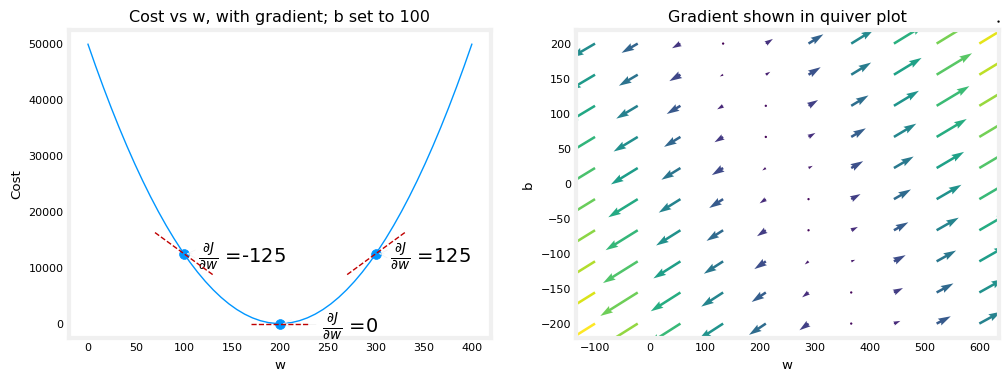

In [40]:
plt_gradients(x_train,y_train, compute_cost, compute_gradient)
plt.show()

In [41]:
def gradient_descent(x,y,w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  """
  Perform gradient descent to fit w,b. Update w,b by taking num_iters gradient steps with elarning rate alphas

  Returns:
  w : updated value of parameter after running gradient descent
  b: updatd after gd
  J_history : hisotry of cost values
  p_history : history of parameters [w,b]
  """

  # An array to store cost J and w's at each iteration primarily for graphin later
  J_history =[]
  p_history = []
  b = b_in
  w = w_in

  for i in range(num_iters):
    # calculate teh gradient and update the parameters using gradient_function
    # basically figure out which direction to move
    dj_dw, dj_db, = compute_gradient(x,y,w,b)

    # Update Parameters (move to the bottom where slope/gradient ->0)
    b = b - alpha * dj_db
    w = w - alpha * dj_dw

    # Save cost J at each iterantion. # optional to check how we're doing
    # cost isn't actaully used in the descent(it's derivate is)
    if i<100000:  # only save for first 100,000 iterations to avoid memory consumption from list
      J_history.append(cost_function(x,y,w,b))
      p_history.append([w,b])
    # Print cost every intervaal 1- times or as many interation if <10
    if i % math.ceil(num_iters/10) ==0:
      print(
        f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",  # :4 = minimum width 4; 0.2e = scientific notation, 2 decimals
        f"dj_dw: {dj_dw:0.3e}, dj_db: {dj_db:0.3e}  ",  # 0.3e = scientific notation, 3 decimals
        f"w: {w:0.3e}, b:{b:0.5e}")                       # w: 3 decimals, b: 5 decimals (scientific notation)
  return w, b, J_history, p_history

In [52]:
# inittialize parameters
w_init = 0
b_init = 0

# some gradient descen sttings

iterations = 100000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train,w_init, b_init, tmp_alpha,  iterations, compute_cost, compute_gradient  )

print(f"(w,b) found by gradient desccent: ({w_final:8.4f}, {b_final:8.4f})")
# {w_final:8.4f}
# 8   → minimum width of 8 characters
# .4  → 4 digits after the decimal point
# f   → fixed-point (normal decimal) notation

Iteration    0: Cost 8.21e+04  dj_dw: -3.250e+02, dj_db: -2.000e+02   w: 3.250e+00, b:2.00000e+00
Iteration 10000: Cost 9.97e-03  dj_dw: -1.003e-02, dj_db: 1.622e-02   w: 1.997e+02, b:1.00445e+02
Iteration 20000: Cost 6.76e-06  dj_dw: -2.611e-04, dj_db: 4.225e-04   w: 2.000e+02, b:1.00012e+02
Iteration 30000: Cost 4.58e-09  dj_dw: -6.799e-06, dj_db: 1.100e-05   w: 2.000e+02, b:1.00000e+02
Iteration 40000: Cost 3.11e-12  dj_dw: -1.771e-07, dj_db: 2.865e-07   w: 2.000e+02, b:1.00000e+02
Iteration 50000: Cost 2.11e-15  dj_dw: -4.611e-09, dj_db: 7.460e-09   w: 2.000e+02, b:1.00000e+02
Iteration 60000: Cost 1.43e-18  dj_dw: -1.203e-10, dj_db: 1.942e-10   w: 2.000e+02, b:1.00000e+02
Iteration 70000: Cost 1.06e-21  dj_dw: -3.837e-12, dj_db: 4.945e-12   w: 2.000e+02, b:1.00000e+02
Iteration 80000: Cost 5.05e-23  dj_dw: -1.421e-12, dj_db: 7.105e-13   w: 2.000e+02, b:1.00000e+02
Iteration 90000: Cost 5.05e-23  dj_dw: -1.421e-12, dj_db: 7.105e-13   w: 2.000e+02, b:1.00000e+02
(w,b) found by gradi

- The cost starts large and rapidly declines
- The partial derivateives, dj_dw and dj_db also get smaller , rapidly at first and then more slowly.As the process nears the 'bottom fo the bowl' progress is slwoer due to the smaller value of the derivatives at that point
- progress slwos although hte learning rate, alpha  remains fixed.


In [53]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


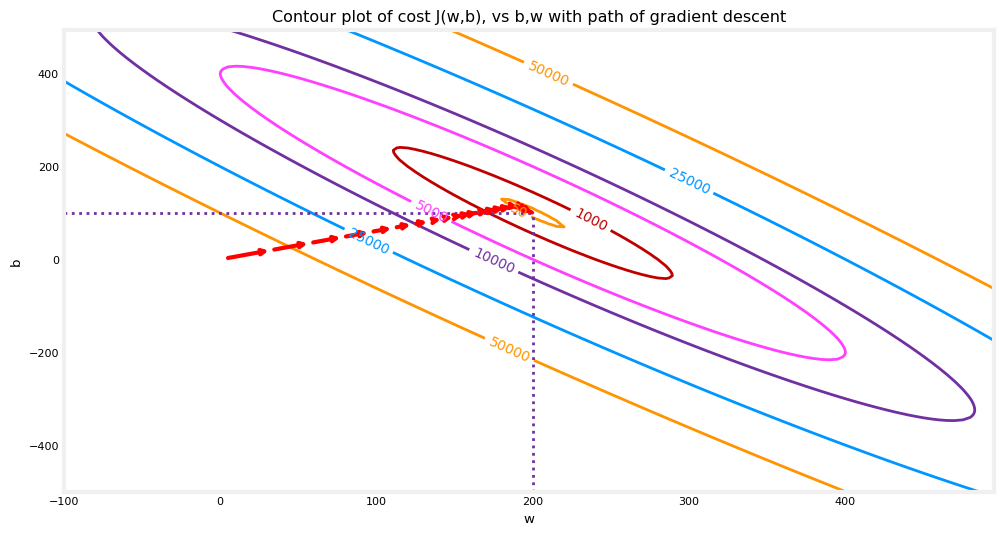

In [54]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, p_hist, ax)

# Increased learning rate

In [57]:
w_init= 0
b_init = 0

# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1

# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 1.17e+04  dj_dw: -3.250e+02, dj_db: -2.000e+02   w: 2.600e+02, b:1.60000e+02
Iteration    1: Cost 1.62e+03  dj_dw: 1.200e+02, dj_db: 7.500e+01   w: 1.640e+02, b:1.00000e+02
Iteration    2: Cost 2.33e+02  dj_dw: -4.500e+01, dj_db: -2.700e+01   w: 2.000e+02, b:1.21600e+02
Iteration    3: Cost 4.20e+01  dj_dw: 1.620e+01, dj_db: 1.080e+01   w: 1.870e+02, b:1.12960e+02
Iteration    4: Cost 1.51e+01  dj_dw: -6.480e+00, dj_db: -3.240e+00   w: 1.922e+02, b:1.15552e+02
Iteration    5: Cost 1.09e+01  dj_dw: 1.944e+00, dj_db: 1.944e+00   w: 1.907e+02, b:1.13997e+02
Iteration    6: Cost 9.80e+00  dj_dw: -1.166e+00, dj_db: 0.000e+00   w: 1.916e+02, b:1.13997e+02
Iteration    7: Cost 9.17e+00  dj_dw: 1.421e-14, dj_db: 6.998e-01   w: 1.916e+02, b:1.13437e+02
Iteration    8: Cost 8.63e+00  dj_dw: -4.199e-01, dj_db: 4.199e-01   w: 1.919e+02, b:1.13101e+02
Iteration    9: Cost 8.13e+00  dj_dw: -2.519e-01, dj_db: 5.039e-01   w: 1.921e+02, b:1.12698e+02


the derivatives sign is changing each iteration and its clear that ithe learning rate is too large and hte solution is diverging